## 数据该怎么办？
通常，当你需要处理图像、文本、音频或视频数据时，可以使用标准的 Python 库将数据加载到 numpy 数组中。然后，你可以将这个数组转换为 torch.*Tensor。

对于图像，Pillow、OpenCV 等包很有用

对于音频，scipy 和 librosa 等包很有用

对于文本，使用原生 Python 或基于 Cython 的加载方式，或者 NLTK 和 SpaCy 很有用

专门针对视觉任务，我们创建了一个名为 torchvision 的包，其中包含了针对常用数据集（如 ImageNet、CIFAR10、MNIST 等）的数据加载器，以及用于图像的数据转换工具，即 torchvision.datasets 和 torch.utils.data.DataLoader。

这提供了极大的便利，避免了编写模板代码。

## 训练图像分类器
我们将按顺序执行以下步骤

使用 torchvision 加载并归一化 CIFAR10 训练集和测试集

定义卷积神经网络

定义损失函数

在训练数据上训练网络

在测试数据上测试网络

# 1. 加载并归一化 CIFAR10

In [1]:
import torch
import torchvision
from torchvision.transforms import v2

In [2]:
import sys
print(sys.executable)

D:\Anaconda\envs\pytorch\python.exe


In [3]:
!{sys.executable} -m pip install matplotlib

In [4]:
import matplotlib
print(matplotlib.__version__)

3.11.1


torchvision 数据集的输出是范围在 [0, 1] 之间的 PILImage 图像。我们将它们转换为归一化范围在 [-1, 1] 之间的张量（Tensor）。

In [5]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

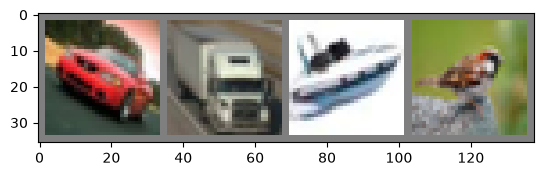

car   truck ship  bird 


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

# 2. 定义卷积神经网络
从之前的“神经网络”章节中复制神经网络代码，并将其修改为接收 3 通道图像（而不是原先定义的 1 通道图像）。

In [7]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

# 3. 定义损失函数和优化器
我们使用分类交叉熵损失函数和带有动量的随机梯度下降（SGD）。

In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# 4. 训练网络
这是事情变得有趣的地方。我们只需遍历数据迭代器，将输入送入网络并进行优化即可。

In [9]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.212
[1,  4000] loss: 1.853
[1,  6000] loss: 1.666
[1,  8000] loss: 1.582
[1, 10000] loss: 1.526
[1, 12000] loss: 1.473
[2,  2000] loss: 1.400
[2,  4000] loss: 1.394
[2,  6000] loss: 1.371
[2,  8000] loss: 1.325
[2, 10000] loss: 1.337
[2, 12000] loss: 1.304
Finished Training


In [10]:
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)

# 5. 在测试数据上测试网络
我们已经在训练数据集上完成了 2 轮训练。但我们需要检查网络是否学到了任何东西。

我们将通过预测神经网络输出的类别标签，并将其与真实值进行比对来完成。如果预测正确，我们将该样本添加到正确预测的列表中。

好了，第一步。让我们显示一张测试集中的图像来熟悉一下。

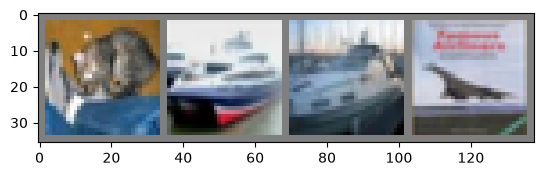

GroundTruth:  cat   ship  ship  plane


In [11]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [13]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [14]:
outputs = net(images)

In [15]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   car   ship  ship 


In [16]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 52 %


In [17]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 53.4 %
Accuracy for class: car   is 57.0 %
Accuracy for class: bird  is 34.6 %
Accuracy for class: cat   is 40.0 %
Accuracy for class: deer  is 43.9 %
Accuracy for class: dog   is 32.4 %
Accuracy for class: frog  is 75.9 %
Accuracy for class: horse is 48.5 %
Accuracy for class: ship  is 87.7 %
Accuracy for class: truck is 53.5 %


# 在 GPU 上训练
就像你将张量转移到 GPU 上一样，你也可以将神经网络转移到 GPU 上。

如果 CUDA 可用，我们首先将设备定义为第一个可见的 CUDA 设备

In [18]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cpu


In [19]:
net.to(device)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [20]:
inputs, labels = data[0].to(device), data[1].to(device)